In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
data = '''
# n_H      CCSD(T)           AFQMC/CISD                 AFQMC/CCSD_PT             AFQMC/CCSD_PT2          Ref: DMRG
   2     -1.09607128    -1.096072 +/- 0.000000     -1.096182 +/- 0.000008     -1.096168 +/- 0.000010     -1.09607128
   4     -2.16536821    -2.165261 +/- 0.000017     -2.165540 +/- 0.000031     -2.165505 +/- 0.000049     -2.16529411
   8     -4.31390497    -4.313311 +/- 0.000051     -4.314331 +/- 0.000091     -4.314299 +/- 0.000091     -4.31381598
   16    -8.61854700    -8.615924 +/- 0.000147     -8.619288 +/- 0.000241     -8.619091 +/- 0.000231     -8.61885659
   32    -17.2312454    -17.221271 +/- 0.000393    -17.232733 +/- 0.000550    -17.232826 +/- 0.000540    -17.23348984
   64    -34.4573081    -34.428642 +/- 0.000878    -34.461329 +/- 0.001979    -34.461195 +/- 0.001979    -34.464990568
'''

In [3]:
n = []
# afqmc_hf = []
ccsd_t = []
afqmc_ci = []
afqmc_pt = []
afqmc_pt2 = []
ref = []
afqmc_hf_err = []
afqmc_ci_err = []
afqmc_pt_err = []
afqmc_pt2_err = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd_t = np.hstack((ccsd_t,float(parts[1])/int(parts[0])))
        # afqmc_hf = np.hstack((afqmc_hf,float(parts[1])/int(parts[0])))
        # afqmc_hf_err = np.hstack((afqmc_hf_err,float(parts[3])/int(parts[0])))
        afqmc_ci = np.hstack((afqmc_ci,float(parts[2])/int(parts[0])))
        afqmc_ci_err = np.hstack((afqmc_ci_err,float(parts[4])/int(parts[0])))
        afqmc_pt = np.hstack((afqmc_pt,float(parts[5])/int(parts[0])))
        afqmc_pt_err = np.hstack((afqmc_pt_err,float(parts[7])/int(parts[0])))
        afqmc_pt2 = np.hstack((afqmc_pt2,float(parts[8])/int(parts[0])))
        afqmc_pt2_err = np.hstack((afqmc_pt2_err,float(parts[10])/int(parts[0])))
        ref = np.hstack((ref,float(parts[11])/int(parts[0])))


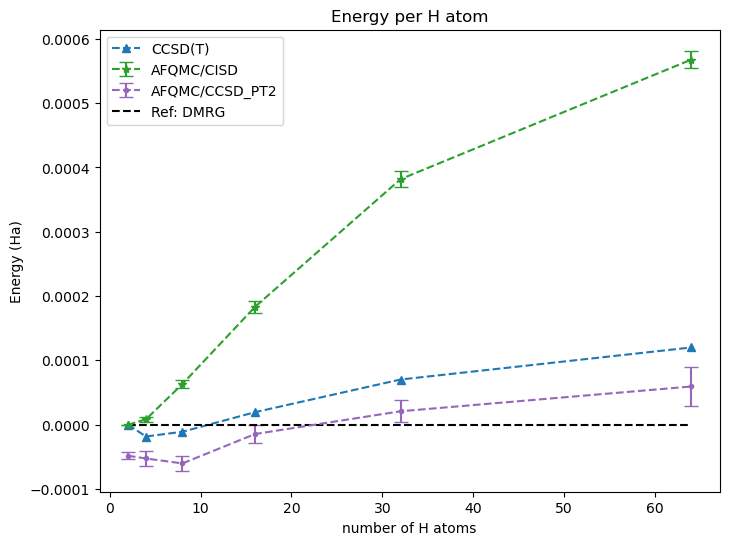

In [4]:
# plt.errorbar(n,afqmc_hf-ref,yerr=afqmc_hf_err,fmt='x--', capsize=5, color='C1', label='AFQMC/HF')
plt.figure(figsize=(8, 6))
plt.plot(n,ccsd_t-ref,'^--',color='C0', label='CCSD(T)')
plt.errorbar(n,afqmc_ci-ref,yerr=afqmc_ci_err,fmt='*--', capsize=5, color='C2', label='AFQMC/CISD')
# plt.errorbar(n,afqmc_pt-ref,yerr=afqmc_pt_err,fmt='.--', capsize=5, color='C3', label='AFQMC/CCSD_PT')
plt.errorbar(n,afqmc_pt2-ref,yerr=afqmc_pt2_err,fmt='.--', capsize=5, color='C4', label='AFQMC/CCSD_PT2')
plt.plot(n,ref-ref,'--',color='black', label='Ref: DMRG')
plt.xlabel('number of H atoms')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H atom')
handles, labels = plt.gca().get_legend_handles_labels()
order = ['CCSD(T)', 'AFQMC/CISD', 'AFQMC/CCSD_PT2', 'Ref: DMRG']
ordered_handles = [handles[labels.index(l)] for l in order]
ordered_labels = order
plt.legend(ordered_handles, ordered_labels, ) #bbox_to_anchor=(0.8, 0.8)) #loc='upper left')
plt.show()

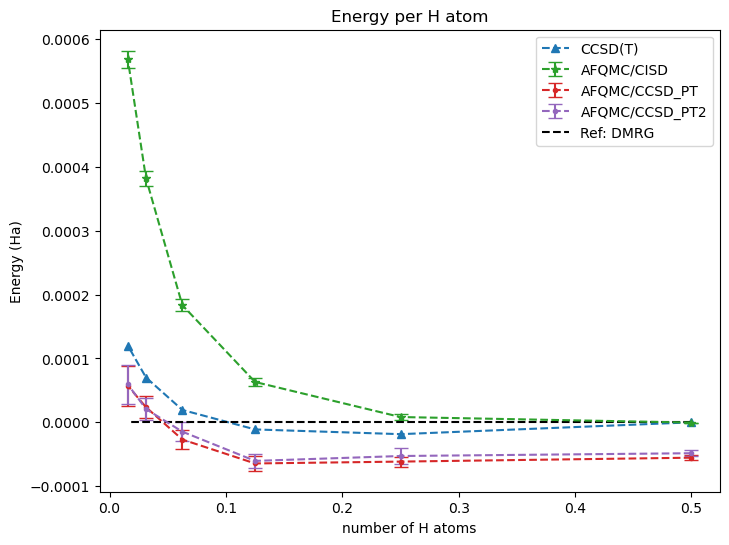

In [5]:
plt.figure(figsize=(8, 6))
plt.plot(1/n,ccsd_t-ref,'^--',color='C0', label='CCSD(T)')
plt.errorbar(1/n,afqmc_ci-ref,yerr=afqmc_ci_err,fmt='*--', capsize=5, color='C2', label='AFQMC/CISD')
plt.errorbar(1/n,afqmc_pt-ref,yerr=afqmc_pt_err,fmt='.--', capsize=5, color='C3', label='AFQMC/CCSD_PT')
plt.errorbar(1/n,afqmc_pt2-ref,yerr=afqmc_pt2_err,fmt='.--', capsize=5, color='C4', label='AFQMC/CCSD_PT2')
plt.plot(1/n,ref-ref,'--',color='black', label='Ref: DMRG')
plt.xlabel('number of H atoms')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H atom')
handles, labels = plt.gca().get_legend_handles_labels()
order = ['CCSD(T)', 'AFQMC/CISD', 'AFQMC/CCSD_PT', 'AFQMC/CCSD_PT2', 'Ref: DMRG']
ordered_handles = [handles[labels.index(l)] for l in order]
ordered_labels = order
plt.legend(ordered_handles, ordered_labels, ) #bbox_to_anchor=(0.8, 0.8)) #loc='upper left')
plt.show()

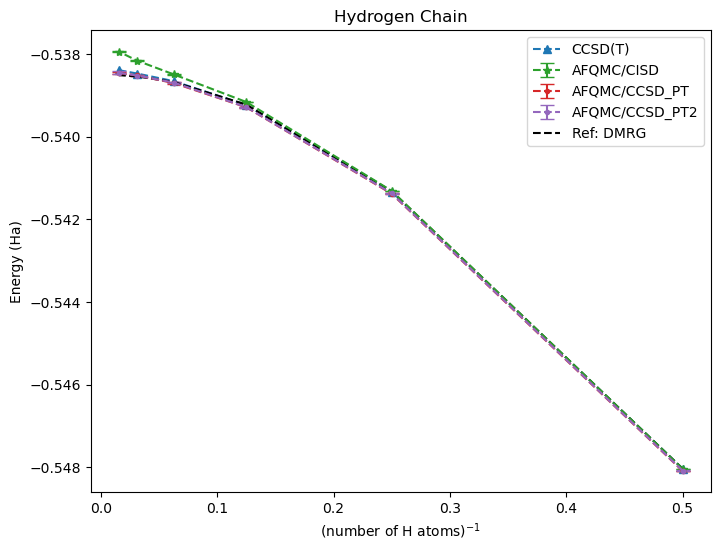

In [15]:
plt.figure(figsize=(8, 6))
plt.plot(1/n,ccsd_t,'^--',color='C0', label='CCSD(T)')
plt.errorbar(1/n,afqmc_ci,yerr=afqmc_ci_err,fmt='*--', capsize=5, color='C2', label='AFQMC/CISD')
plt.errorbar(1/n,afqmc_pt,yerr=afqmc_pt_err,fmt='.--', capsize=5, color='C3', label='AFQMC/CCSD_PT')
plt.errorbar(1/n,afqmc_pt2,yerr=afqmc_pt2_err,fmt='.--', capsize=5, color='C4', label='AFQMC/CCSD_PT2')
plt.plot(1/n,ref,'--',color='black', label='Ref: DMRG')
plt.xlabel('(number of H atoms)$^{-1}$')
plt.ylabel('Energy (Ha)')
plt.title('Hydrogen Chain')
handles, labels = plt.gca().get_legend_handles_labels()
order = ['CCSD(T)', 'AFQMC/CISD', 'AFQMC/CCSD_PT', 'AFQMC/CCSD_PT2', 'Ref: DMRG']
ordered_handles = [handles[labels.index(l)] for l in order]
ordered_labels = order
plt.legend(ordered_handles, ordered_labels, ) #bbox_to_anchor=(0.8, 0.8)) #loc='upper left')
plt.show()

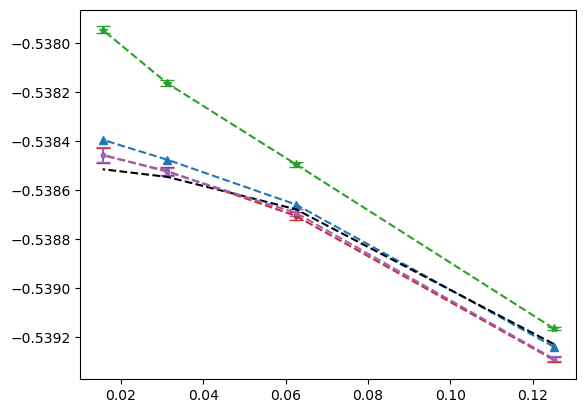

In [16]:
# plt.figure(figsize=(8, 6))
plt.plot(1/n[-4:],ccsd_t[-4:],'^--',color='C0', label='CCSD(T)')
plt.errorbar(1/n[-4:],afqmc_ci[-4:],yerr=afqmc_ci_err[-4:],fmt='*--', capsize=5, color='C2', label='AFQMC/CISD')
plt.errorbar(1/n[-4:],afqmc_pt[-4:],yerr=afqmc_pt_err[-4:],fmt='.--', capsize=5, color='C3', label='AFQMC/CCSD_PT')
plt.errorbar(1/n[-4:],afqmc_pt2[-4:],yerr=afqmc_pt2_err[-4:],fmt='.--', capsize=5, color='C4', label='AFQMC/CCSD_PT2')
plt.plot(1/n[-4:],ref[-4:],'--',color='black', label='Ref: DMRG')
# plt.xlabel('(number of H atoms)$^{-1}$')
# plt.ylabel('Energy (Ha)')
# plt.title('Energy per H atom')
# handles, labels = plt.gca().get_legend_handles_labels()
# order = ['CCSD(T)', 'AFQMC/CISD', 'AFQMC/CCSD_PT', 'AFQMC/CCSD_PT2', 'Ref: DMRG']
# ordered_handles = [handles[labels.index(l)] for l in order]
# ordered_labels = order|
# plt.legend(ordered_handles, ordered_labels, ) #bbox_to_anchor=(0.8, 0.8)) #loc='upper left')
plt.show()

In [17]:
inv_n = 1/n[-2:]
ref_lst = ref[-2:]
ccsd_t_lst = ccsd_t[-2:]
afqmc_ci_lst = afqmc_ci[-2:]
afqmc_pt_lst = afqmc_pt[-2:]
afqmc_pt2_lst = afqmc_pt2[-2:]
afqmc_ci_err_lst = afqmc_ci_err[-2:]
afqmc_pt_err_lst = afqmc_pt_err[-2:]
afqmc_pt2_err_lst = afqmc_pt2_err[-2:]

In [19]:
def extraplote_2pts(x,y,dy=None):
    # y = k*x + b
    x1, x2 = x
    y1, y2 = y

    # k = (y2 - y1) / (x2 - x1)
    b = (y1 * x2 - y2 * x1) / (x2 - x1)
    
    if dy is not None:
        dy1, dy2 = dy
        b_err = np.sqrt((x2*dy1/(x2-x1))**2 + (x1*dy2/(x2-x1))**2)
        return b, b_err
    
    else:
        return b

In [20]:
ref_ext = extraplote_2pts(inv_n,ref_lst)
ccsd_t_ext = extraplote_2pts(inv_n,ccsd_t_lst)
afqmc_ci_ext, afqmc_ci_err_ext = extraplote_2pts(inv_n,afqmc_ci_lst,dy=afqmc_ci_err_lst)
afqmc_pt_ext, afqmc_pt_err_ext = extraplote_2pts(inv_n,afqmc_pt_lst,dy=afqmc_pt_err_lst)
afqmc_pt2_ext, afqmc_pt2_err_ext = extraplote_2pts(inv_n,afqmc_pt2_lst,dy=afqmc_pt2_err_lst)

In [21]:
print('size extrapolate')
print(f'ccsd_t TDL energy = {ccsd_t_ext:.5f}')
print(f'AFQMC/CISD TDL energy = {afqmc_ci_ext:.5f} +/- {afqmc_ci_err_ext:.5f}')
print(f'AFQMC/CCSD_PT TDL energy = {afqmc_pt_ext:.5f} +/- {afqmc_pt_err_ext:.5f}')
print(f'AFQMC/CCSD_PT2 TDL energy = {afqmc_pt2_ext:.5f} +/- {afqmc_pt2_err_ext:.5f}')
print(f'DMRG ref TDL energy = {ref_ext:.5f}')

size extrapolate
ccsd_t TDL energy = -0.53831
AFQMC/CISD TDL energy = -0.53773 +/- 0.00003
AFQMC/CCSD_PT TDL energy = -0.53839 +/- 0.00006
AFQMC/CCSD_PT2 TDL energy = -0.53839 +/- 0.00006
DMRG ref TDL energy = -0.53848


In [22]:
def inv_n2_ext(x,y,y_err=None):
    '''
    fitting Energy vs (num. of basis)^(-1)
    E(1/m) = a + b*(1/n) + c*(1/n)**2
    '''
    A = np.column_stack([
        np.ones_like(x), 
        x,
        x**2
        ])

    if y_err is not None:
        # weighted least squares
        W = np.diag(1 / y_err**2)
        cov = np.linalg.inv(A.T @ W @ A)
        (a,b,c) = cov @ (A.T @ W @ y)
        (da,db,dc) = np.sqrt(np.diag(cov))
    else:
        (a, b, c), residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)

        N = len(x)
        sigma2 = residuals[0] / (N - 3)      # variance of residuals
        cov = sigma2 * np.linalg.inv(A.T @ A)
        (da,db,dc) = np.sqrt(np.diag(cov))

    return (a,b,c), (da,db,dc)

In [23]:
print('size extrapolate 1/N^2')
(a1,b1,c1), (da1,db1,dc1) = inv_n2_ext(1/n[-4:],ccsd_t[-4:])
print(f'ccsd_t TDL energy = {a1:.5f} +/- {da1:.5f}')
(a2,b2,c2), (da2,db2,dc2) = inv_n2_ext(1/n[-4:],afqmc_ci[-4:],afqmc_ci_err[-4:])
print(f'AFQMC/CISD TDL energy = {a2:.5f} +/- {da2:.5f}')
(a3,b3,c3), (da3,db3,dc3) = inv_n2_ext(1/n[-4:],afqmc_pt[-4:],afqmc_pt_err[-4:])
print(f'AFQMC/CCSD_PT TDL energy = {a3:.5f} +/- {da3:.5f}')
(a4,b4,c4), (da4,db4,dc4) = inv_n2_ext(1/n[-4:],afqmc_pt2[-4:],afqmc_pt2_err[-4:])
print(f'AFQMC/CCSD_PT TDL energy = {a4:.5f} +/- {da4:.5f}')
(a5,b5,c5), (da5,db5,dc5) = inv_n2_ext(1/n[-4:],ref[-4:])
print(f'DMRG ref TDL energy = {a5:.5f} +/- {da5:.5f}')

size extrapolate 1/N^2
ccsd_t TDL energy = -0.53834 +/- 0.00001
AFQMC/CISD TDL energy = -0.53777 +/- 0.00002
AFQMC/CCSD_PT TDL energy = -0.53841 +/- 0.00004
AFQMC/CCSD_PT TDL energy = -0.53843 +/- 0.00004
DMRG ref TDL energy = -0.53851 +/- 0.00000


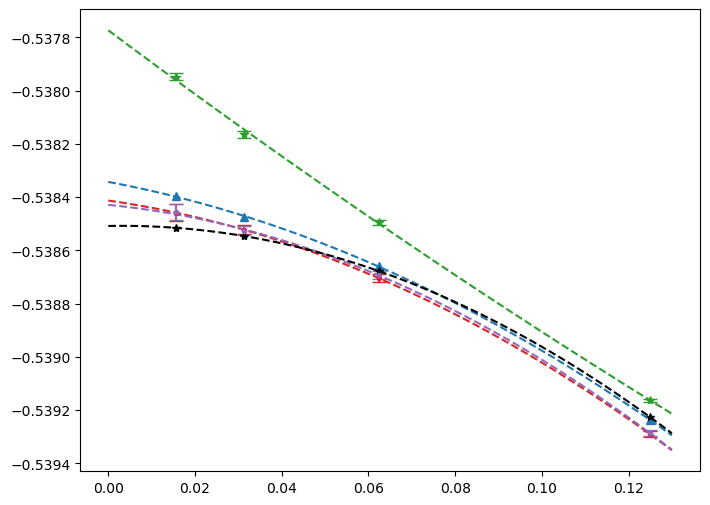

In [24]:
x = np.linspace(0,0.13,100)
y1 = a1 + b1*x + c1*x**2
y2 = a2 + b2*x + c2*x**2
y3 = a3 + b3*x + c3*x**2
y4 = a4 + b4*x + c4*x**2
y5 = a5 + b5*x + c5*x**2

plt.figure(figsize=(8, 6))
plt.plot(1/n[-4:],ccsd_t[-4:],'^',color='C0', label='CCSD(T)')
plt.errorbar(1/n[-4:],afqmc_ci[-4:],yerr=afqmc_ci_err[-4:],fmt='*', capsize=5, color='C2', label='AFQMC/CISD')
plt.errorbar(1/n[-4:],afqmc_pt[-4:],yerr=afqmc_pt_err[-4:],fmt='.', capsize=5, color='C3', label='AFQMC/CCSD_PT')
plt.errorbar(1/n[-4:],afqmc_pt2[-4:],yerr=afqmc_pt2_err[-4:],fmt='.', capsize=5, color='C4', label='AFQMC/CCSD_PT2')
plt.plot(1/n[-4:],ref[-4:],'*',color='black', label='Ref: DMRG')

plt.plot(x,y1,'--',color='C0',label='CCSD(T)(fit)')
plt.plot(x,y2,'--',color='C2',label='AFQMC/CISD(fit)')
plt.plot(x,y3,'--',color='C3',label='AFQMC/CCSD_PT(fit)')
plt.plot(x,y4,'--',color='C4',label='AFQMC/CCSD_PT2(fit)')
plt.plot(x,y5,'--',color='black',label='Ref: DMRG')
# plt.xlabel('(number of H atoms)$^{-1}$')
# plt.ylabel('Energy (Ha)')
# plt.title('Energy per H atom')
# handles, labels = plt.gca().get_legend_handles_labels()
# order = ['CCSD(T)', 'AFQMC/CISD', 'AFQMC/CCSD_PT', 'AFQMC/CCSD_PT2', 'Ref: DMRG']
# ordered_handles = [handles[labels.index(l)] for l in order]
# ordered_labels = order|
# plt.legend(ordered_handles, ordered_labels, ) #bbox_to_anchor=(0.8, 0.8)) #loc='upper left')
plt.show()

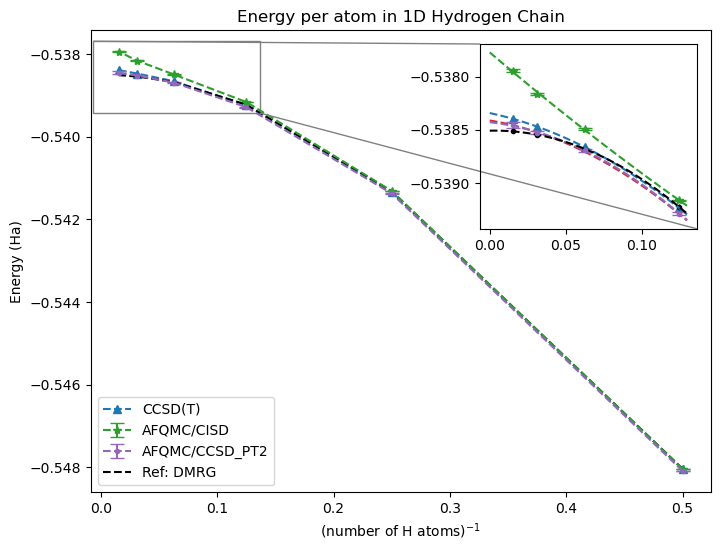

In [25]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(8, 6))

# Main plot
ax.plot(1/n,ccsd_t,'^--',color='C0', label='CCSD(T)')
ax.errorbar(1/n,afqmc_ci,yerr=afqmc_ci_err,fmt='*--', capsize=5, color='C2', label='AFQMC/CISD')
# ax.errorbar(1/n,afqmc_pt,yerr=afqmc_pt_err,fmt='.--', capsize=5, color='C3', label='AFQMC/CCSD_PT')
ax.errorbar(1/n,afqmc_pt2,yerr=afqmc_pt2_err,fmt='.--', capsize=5, color='C4', label='AFQMC/CCSD_PT2')
ax.plot(1/n,ref,'--',color='black', label='Ref: DMRG')
# ax.set_xlim(0, 10)
# ax.set_ylim(-1, 1)
ax.set_xlabel("(number of H atoms)$^{-1}$")
ax.set_ylabel("Energy (Ha)")
ax.set_title("Energy per atom in 1D Hydrogen Chain")
# handles, labels = ax.gca().get_legend_handles_labels()
order = ['CCSD(T)', 'AFQMC/CISD', 'AFQMC/CCSD_PT2', 'Ref: DMRG']
ordered_handles = [handles[labels.index(l)] for l in order]
ordered_labels = order
ax.legend(ordered_handles, ordered_labels, loc='lower left')

# Inset axes (x0, y0, width, height) in axes fraction
axins = inset_axes(
    ax,
    width="35%", height="40%",
    loc="upper right",
    borderpad=1
)

# axins.plot(x, y)
axins.plot(1/n[-4:],ccsd_t[-4:],'^',color='C0')
axins.errorbar(1/n[-4:],afqmc_ci[-4:],yerr=afqmc_ci_err[-4:],fmt='*', capsize=5, color='C2')
# axins.errorbar(1/n[-4:],afqmc_pt[-4:],yerr=afqmc_pt_err[-4:],fmt='.', capsize=5, color='C3')
axins.errorbar(1/n[-4:],afqmc_pt2[-4:],yerr=afqmc_pt2_err[-4:],fmt='.', capsize=5, color='C4')
axins.plot(1/n[-4:],ref[-4:],'.',color='black', label='Ref: DMRG')
axins.plot(x,y1,'--',color='C0',label='CCSD(T)(fit)')
axins.plot(x,y2,'--',color='C2',label='AFQMC/CISD(fit)')
axins.plot(x,y3,'--',color='C3',label='AFQMC/CCSD_PT(fit)')
axins.plot(x,y4,'--',color='C4',label='AFQMC/CCSD_PT2(fit)')
axins.plot(x,y5,'--',color='black',label='Ref: DMRG')
# axins.set_xlim(0, 0.2)    # zoom region
# axins.set_ylim(0.5, 0.5)

# Optional: show zoom box
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()